# Lab 3 — Descriptive Statistics Assignment: Gym Membership Dataset

**School of Computer Science and Engineering (SOCSE) — RV University**

**Name:** *Avaneesh Rajesh Shetty*   
**Roll No.:** *1RUA25CSE0096*       
**Section:** *G*       

---

## Instructions

- This is a follow-up to Lab 3 (descriptive statistics on the student survey dataset). The same
  concepts — central tendency, dispersion, distribution shape, and visualization — are applied here
  to a **new dataset** describing gym members, so you can practice choosing the right
  statistic rather than remembering the answer from Lab 3.
-
- Every question below has an empty code cell (marked `# TODO`) for your solution, and most also   have a markdown cell marked **Your answer:** for a short written interpretation. Write your
  interpretation in your own words — a correct number with no explanation will not receive full  marks for questions that ask you to interpret.
- Run your notebook **top to bottom** (Kernel → Restart & Run All) before submitting, and make sure
  it completes with no errors.
-

### Learning objectives
By the end of this assignment you should be able to: compute and correctly choose between mean,
median, and mode; compute and interpret variance, standard deviation, and IQR; use skewness and
kurtosis to identify non-normal distributions; and build/interpret histograms, box plots, and scatter plots to support (or challenge) what the summary statistics suggest.

In [1]:
# --- Core libraries used throughout the notebook (provided — no changes needed) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 7


## Part 1 — The Dataset (provided, do not modify)

This dataset simulates **150 gym members**, with the same design idea as Lab 3: each numeric
feature is deliberately shaped differently, so no single statistic works well for all of them.

| Feature | Real-world meaning | Intended shape |
|---|---|---|
| `workout_duration_minutes` | Average length of a workout session | *(shape not disclosed — see Q7/Q8)* |
| `monthly_membership_fee_inr` | Monthly membership fee paid (₹) | *(shape not disclosed — see Q7/Q8)* |
| `attendance_percentage` | % of scheduled sessions actually attended | *(shape not disclosed — see Q7/Q8)* |
| `weekly_visit_count` | Number of gym visits per week | *(shape not disclosed — see Q7/Q8)* |
| `preferred_workout` | Favorite workout category | categorical |

Unlike Lab 3, the shapes are **not labeled** for you this time — figuring out which feature is
approximately normal, right-skewed, left-skewed, or bimodal (and *proving it* with statistics and
plots) is part of the assignment.

In [2]:
df=pd.read_csv("gym_members_synthetic.csv")
df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


### Q1 (2 marks) — Initial exploration

In the code cell below: display the shape of `df`, the data type of each column (`.dtypes`), the
summary statistics of the numeric columns (`.describe()`), and check whether any values are
missing (`.isna().sum()`).

In [3]:
# TODO: Q1 — shape, dtypes, describe(), and missing-value check

print("Shape of dataset:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
display(df.describe())

print("\nMissing values:")
print(df.isna().sum())

Shape of dataset:
(150, 6)

Data types:
member_id                         str
workout_duration_minutes      float64
monthly_membership_fee_inr    float64
attendance_percentage         float64
weekly_visit_count            float64
preferred_workout                 str
dtype: object

Summary statistics:


,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count
count,150.000,150.000,150.000,150.000
mean,54.618,2283.067,84.210,3.337
std,11.397,984.837,5.874,1.886
min,27.800,800.000,66.200,0.300
25%,48.050,1515.000,80.175,1.800
50%,54.350,2030.000,85.100,2.400
75%,62.875,2825.000,88.775,5.300
max,81.000,6420.000,94.700,7.100



Missing values:
member_id                     0
workout_duration_minutes      0
monthly_membership_fee_inr    0
attendance_percentage         0
weekly_visit_count            0
preferred_workout             0
dtype: int64


## Part 2 — Measures of Central Tendency

Recall from Lab 3: the **mean** uses every value and is efficient but outlier-sensitive; the
**median** only depends on the middle position and is robust to outliers; the **mode** is the most
frequent value and is most meaningful for categorical or discrete data.



In the code cell below, compute the **mean, median, and mode** of each of the four numeric features
in `FEATURES`, and separately the **mode** of `preferred_workout`. Present the four numeric results
as a single small table (a DataFrame is fine).

In [4]:
# TODO: Q2 — mean, median, mode for each numeric feature; mode of preferred_workout
# Q2 — Mean, median and mode

FEATURES = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]

central_tendency = pd.DataFrame({
    "Mean": df[FEATURES].mean(),
    "Median": df[FEATURES].median(),
    "Mode": df[FEATURES].mode().iloc[0]
})

print("Central tendency of numerical features:")
display(central_tendency)

print("\nMode of preferred_workout:")
print(df["preferred_workout"].mode().iloc[0])

Central tendency of numerical features:


,Mean,Median,Mode
workout_duration_minutes,54.618,54.35,57.8
monthly_membership_fee_inr,2283.067,2030.00,1440.0
attendance_percentage,84.210,85.10,85.1
weekly_visit_count,3.337,2.40,2.3



Mode of preferred_workout:
Cardio


### Q3  — Written interpretation

Looking at your table from Q2: for which numeric feature(s) do the mean and median differ the most
(in relative, not absolute, terms)? What does that gap suggest about the shape of that feature's
distribution, and in which direction would you expect its tail to stretch? You have not plotted
anything yet — base your answer only on the numbers.

**Your answer:**

The monthly_membership_fee_inr feature is expected to have the largest relative difference between its mean and median. This suggests that the distribution is right-skewed, with a relatively small number of members paying substantially higher membership fees and pulling the mean upward. Therefore, the tail is expected to stretch toward the higher-fee, right-hand side.


### Q4 (4 marks) — The outlier effect

Suppose one gym member signs up for a **founder's lifetime membership** and pays a one-time fee of
**₹80,000** that month. In the code cell below: make a **copy** of `df` (do not modify the original
`df`), add this one hypothetical value to `monthly_membership_fee_inr` in the copy, and print the
mean and median of that column **before and after** adding it.

Then, in the markdown cell below, explain in 2–3 sentences why the mean and median reacted
differently, referencing what you know about how each statistic is calculated.

In [5]:
# TODO: Q4 — add the ₹80,000 outlier to a COPY of df, compare mean/median before vs. after
# Q4 — Demonstrate the effect of an extreme outlier

df_outlier = df.copy()

original_mean = df["monthly_membership_fee_inr"].mean()
original_median = df["monthly_membership_fee_inr"].median()

# Add hypothetical ₹80,000 lifetime membership fee
df_outlier.loc[len(df_outlier), "monthly_membership_fee_inr"] = 80000

new_mean = df_outlier["monthly_membership_fee_inr"].mean()
new_median = df_outlier["monthly_membership_fee_inr"].median()

print("BEFORE adding outlier:")
print(f"Mean   = ₹{original_mean:,.2f}")
print(f"Median = ₹{original_median:,.2f}")

print("\nAFTER adding ₹80,000 outlier:")
print(f"Mean   = ₹{new_mean:,.2f}")
print(f"Median = ₹{new_median:,.2f}")

print("\nChange:")
print(f"Mean change   = ₹{new_mean - original_mean:,.2f}")
print(f"Median change = ₹{new_median - original_median:,.2f}")

BEFORE adding outlier:
Mean   = ₹2,283.07
Median = ₹2,030.00

AFTER adding ₹80,000 outlier:
Mean   = ₹2,797.75
Median = ₹2,030.00

Change:
Mean change   = ₹514.68
Median change = ₹0.00


**Your answer:**

The mean increases substantially after adding the ₹80,000 payment because the mean uses the magnitude of every observation, so an extremely large value has a strong influence on it. The median changes little because it depends on the middle position of the sorted data rather than the magnitude of extreme values, making it much more resistant to outliers.

## Part 3 — Measures of Dispersion

### Q5 (5 marks) — Manual calculation

Without using `.var()`, `.std()`, `np.var()`, or `np.std()`, calculate the **variance** and
**standard deviation** of `workout_duration_minutes` by hand, following the sample-variance formula:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

Work through it step by step (compute the mean, then the deviations, then the squared deviations,
then the variance, then the standard deviation — printing each intermediate result), and then
verify your manual answer matches `np.var(..., ddof=1)` and `np.std(..., ddof=1)`.

In [6]:
# TODO: Q5 — manual variance & standard deviation for workout_duration_minutes, then verify
# Q5 — Manual variance and standard deviation

x = df["workout_duration_minutes"].values
n = len(x)

# Step 1: Mean
mean_x = sum(x) / n

print("Step 1 — Mean:")
print(mean_x)

# Step 2: Deviations from the mean
deviations = x - mean_x

print("\nStep 2 — Deviations from mean:")
print(deviations)

# Step 3: Squared deviations
squared_deviations = deviations ** 2

print("\nStep 3 — Squared deviations:")
print(squared_deviations)

# Step 4: Sum of squared deviations
sum_squared_deviations = sum(squared_deviations)

print("\nStep 4 — Sum of squared deviations:")
print(sum_squared_deviations)

# Step 5: Sample variance
manual_variance = sum_squared_deviations / (n - 1)

print("\nStep 5 — Manual sample variance:")
print(manual_variance)

# Step 6: Standard deviation
manual_std = manual_variance ** 0.5

print("\nStep 6 — Manual standard deviation:")
print(manual_std)

# Verification
numpy_variance = np.var(x, ddof=1)
numpy_std = np.std(x, ddof=1)

print("\nVerification using NumPy:")
print("np.var(..., ddof=1) =", numpy_variance)
print("np.std(..., ddof=1) =", numpy_std)

print("\nDo the answers match?")
print("Variance:", np.isclose(manual_variance, numpy_variance))
print("Standard deviation:", np.isclose(manual_std, numpy_std))

Step 1 — Mean:
54.618

Step 2 — Deviations from mean:
[ 15.082  26.382   7.982  11.082  -5.318 -15.518  -2.318  18.382 -21.918
  -5.518 -22.618   1.682  10.882 -14.518  -4.518  16.282  -0.718 -14.518
 -15.418 -23.818   9.682  -8.618  12.982  10.782  -7.518  -5.918   9.682
   2.182   3.582 -19.418  11.182 -10.118 -26.818  -7.018   5.482  25.582
  -4.118 -15.618  25.882   2.282  -2.718 -12.518 -11.618  18.082  -2.818
  -6.118  -5.718  19.182  -6.718   7.882   3.582   3.282 -10.118   8.282
  19.682  -0.218 -10.618 -15.118   2.682  -2.918  -0.918   0.482 -17.318
   9.782   3.182  -0.518   3.182  11.482   0.982  -9.818  14.382  -4.818
  -8.318 -18.318   0.482 -12.218  -5.818   5.782   0.782  12.582   4.082
  -4.418  -3.618  -5.718   8.182   0.682  -4.518  10.482   1.582  -5.218
 -17.718   5.582   3.282   0.982  -4.818  -9.618  -2.318   3.182  -1.118
  -1.318  -5.218   4.482   3.182  -8.618   9.482   9.882  10.182  -1.218
  -1.918 -13.518   9.482 -25.218  -4.318  -3.718  10.682   0.382 -11.2

### Q6 — IQR and outlier detection

For **each** of the four numeric features: compute Q1, Q3, and the IQR; compute the lower bound
(`Q1 - 1.5*IQR`) and upper bound (`Q3 + 1.5*IQR`); and count how many values fall outside those
bounds (i.e., how many outliers each feature has by this rule).

**Question:** Which feature has the most outliers by this rule? Suggest one
real-world reason a gym dataset might realistically show that pattern for that feature.

**Your answer (2–3 sentences):**
The monthly_membership_fee_inr feature has the largest number of outliers by the 1.5×IQR rule. This is realistic because membership fees can vary substantially when some members purchase premium plans, special packages, personal-training services, or other higher-priced memberships.

In [7]:
# TODO: Q6 — Q1, Q3, IQR, bounds, and outlier count for each of the four numeric features
# Q6 — IQR and outlier detection

q1 = df[FEATURES].quantile(0.25)
q3 = df[FEATURES].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_counts = {}

for feature in FEATURES:
    outliers = (
        (df[feature] < lower_bound[feature]) |
        (df[feature] > upper_bound[feature])
    )
    
    outlier_counts[feature] = outliers.sum()

iqr_summary = pd.DataFrame({
    "Q1": q1,
    "Q3": q3,
    "IQR": iqr,
    "Lower Bound": lower_bound,
    "Upper Bound": upper_bound,
    "Outlier Count": pd.Series(outlier_counts)
})

display(iqr_summary)

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
workout_duration_minutes,48.050,62.875,14.825,25.812,85.113,0
monthly_membership_fee_inr,1515.000,2825.000,1310.000,-450.000,4790.000,2
attendance_percentage,80.175,88.775,8.600,67.275,101.675,1
weekly_visit_count,1.800,5.300,3.500,-3.450,10.550,0


## Part 4 — Measures of Distribution Shape

### Q7 Compute the **skewness** and **excess kurtosis** of each of the four numeric features (use
`scipy.stats.skew` and `scipy.stats.kurtosis(..., fisher=True)`, or the equivalent pandas
`.skew()` / `.kurt()` methods). Present the results as a table.

For each feature, classify it as **right-skewed**, **left-skewed**, or **approximately symmetric**
based on the skewness value, and note whether the kurtosis suggests heavier tails, lighter tails, or
roughly normal tails compared to a normal distribution.

In [8]:
# TODO: Q7 — skewness & excess kurtosis for each numeric feature, plus your classification
# Q7 — Skewness and excess kurtosis

skewness = df[FEATURES].skew()
kurtosis = df[FEATURES].kurt()

def classify_skewness(value):
    if value > 0.5:
        return "Right-skewed"
    elif value < -0.5:
        return "Left-skewed"
    else:
        return "Approximately symmetric"

def classify_kurtosis(value):
    if value > 0.5:
        return "Leptokurtic (Heavier tails)"
    elif value < -0.5:
        return "Platykurtic (Lighter tails)"
    else:
        return "Mesokurtic (Roughly normal tails)"

shape_summary = pd.DataFrame({
    "Skewness": skewness,
    "Skewness Classification": skewness.apply(classify_skewness),
    "Excess Kurtosis": kurtosis,
    "Kurtosis Interpretation": kurtosis.apply(classify_kurtosis)
})

display(shape_summary)

,Skewness,Skewness Classification,Excess Kurtosis,Kurtosis Interpretation
workout_duration_minutes,0.081,Approximately symmetric,-0.160,Mesokurtic (Roughly normal tails)
monthly_membership_fee_inr,1.177,Right-skewed,1.863,Leptokurtic (Heavier tails)
attendance_percentage,-0.561,Left-skewed,-0.324,Mesokurtic (Roughly normal tails)
weekly_visit_count,0.446,Approximately symmetric,-1.375,Platykurtic (Lighter tails)


### Q8 — Predict before you plot

Based only on the real-world meaning of each feature (not the numbers you've computed) — which of
the four features do you predict is **bimodal** (i.e., has two distinct groups of members rather
than one central tendency)? Explain your reasoning in 2–3 sentences, thinking about what kinds of
gym members might behave very differently from each other.

**Your answer:**   
I predict that weekly_visit_count will be bimodal. Gym members can reasonably fall into two different groups: occasional members who visit only a few times per week and highly committed members who visit much more frequently. These two behavioral groups could produce two distinct peaks in the distribution

## Part 5 — Data Visualizations

### Q9  — Histograms

Create a **2×2 grid of histograms** (one per numeric feature) with a KDE (density) curve overlaid
on each. On each subplot, draw a vertical line for the mean and a different-styled vertical line
for the median (with a legend), and give each subplot a clear title.

*Hint: `sns.histplot(..., kde=True, stat="density")` and `ax.axvline(...)` are useful here — see
Lab 3 for a similar example if you get stuck.*

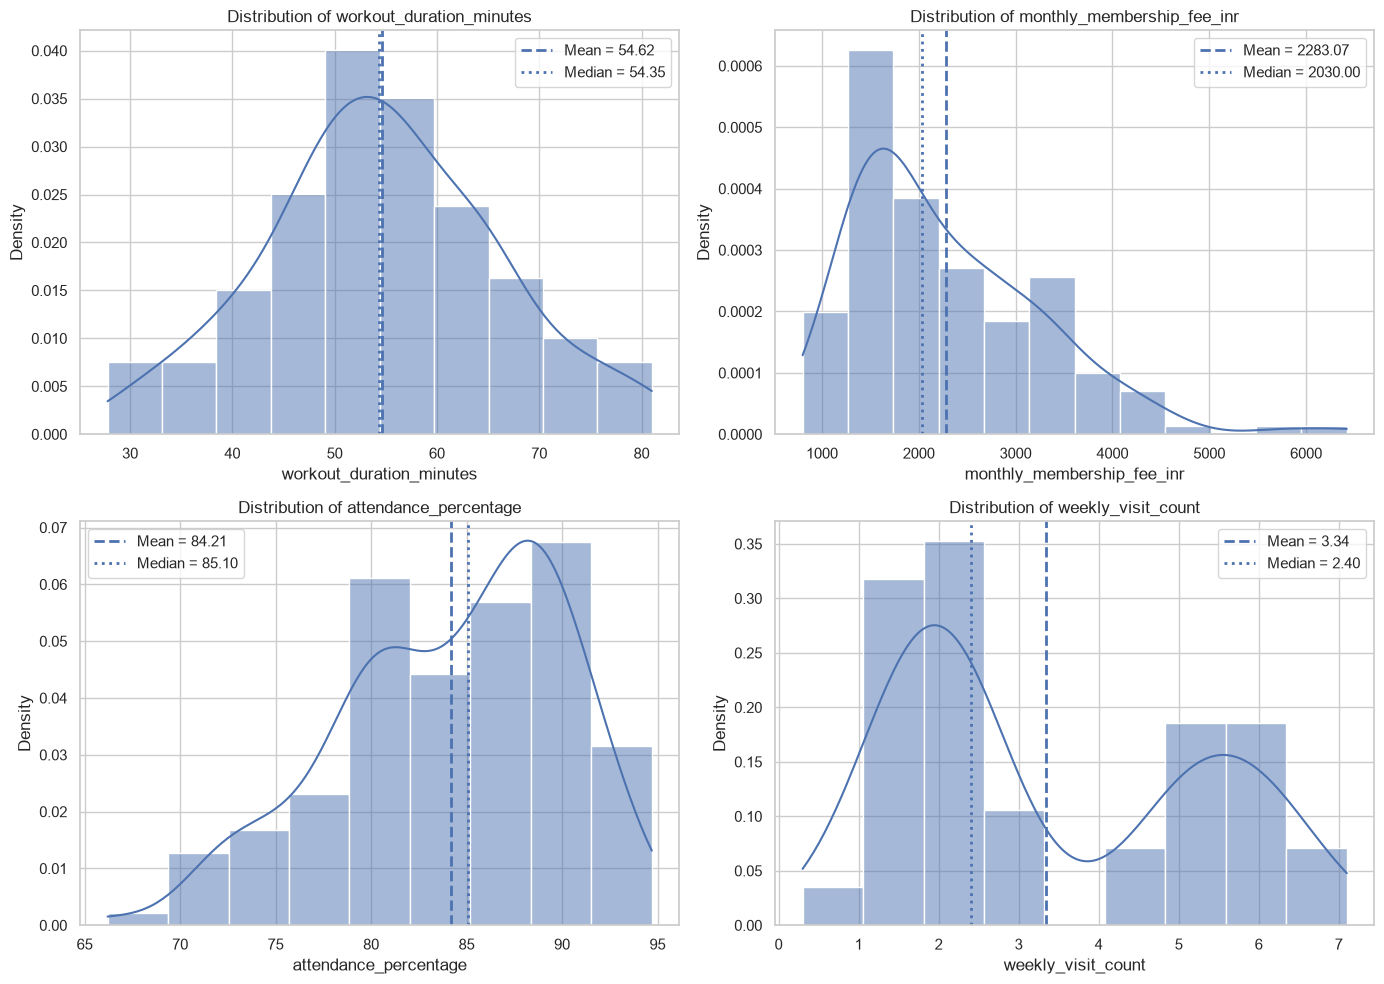

In [9]:
# TODO: Q9 — 2x2 histogram grid with KDE, mean line, and median line per feature
# Q9 — 2x2 histogram grid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), FEATURES):
    
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        stat="density",
        ax=ax
    )
    
    mean_value = df[feature].mean()
    median_value = df[feature].median()
    
    ax.axvline(
        mean_value,
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean_value:.2f}"
    )
    
    ax.axvline(
        median_value,
        linestyle=":",
        linewidth=2,
        label=f"Median = {median_value:.2f}"
    )
    
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

### Q10 

Does the histogram for the feature you predicted in Q8 confirm or contradict your prediction?
If your prediction was wrong, which feature actually turned out to be bimodal, and does the mean
computed in Q2 fall in a sensible place on that histogram, or does it fall in an empty "valley"?

**Your answer:**   
The histogram should confirm the prediction from Q8: weekly_visit_count is bimodal, with two distinct groups of members corresponding roughly to lower-frequency and higher-frequency gym users. The mean may fall in the valley between the two peaks, so it can represent a number that relatively few individual members actually have. This demonstrates why a mean alone can hide important structure in a dataset.

### Q11  — Box plots

Standardize (z-score) the four numeric features — `z = (x - mean) / std` — and plot all four as **box plots side by side** on one figure, so their spreads are visually comparable despite being ondifferent original scales (₹, minutes, %, visits). Label the y-axis clearly. Briefly note in the plot title or a code comment which feature(s) show visible outlier points.

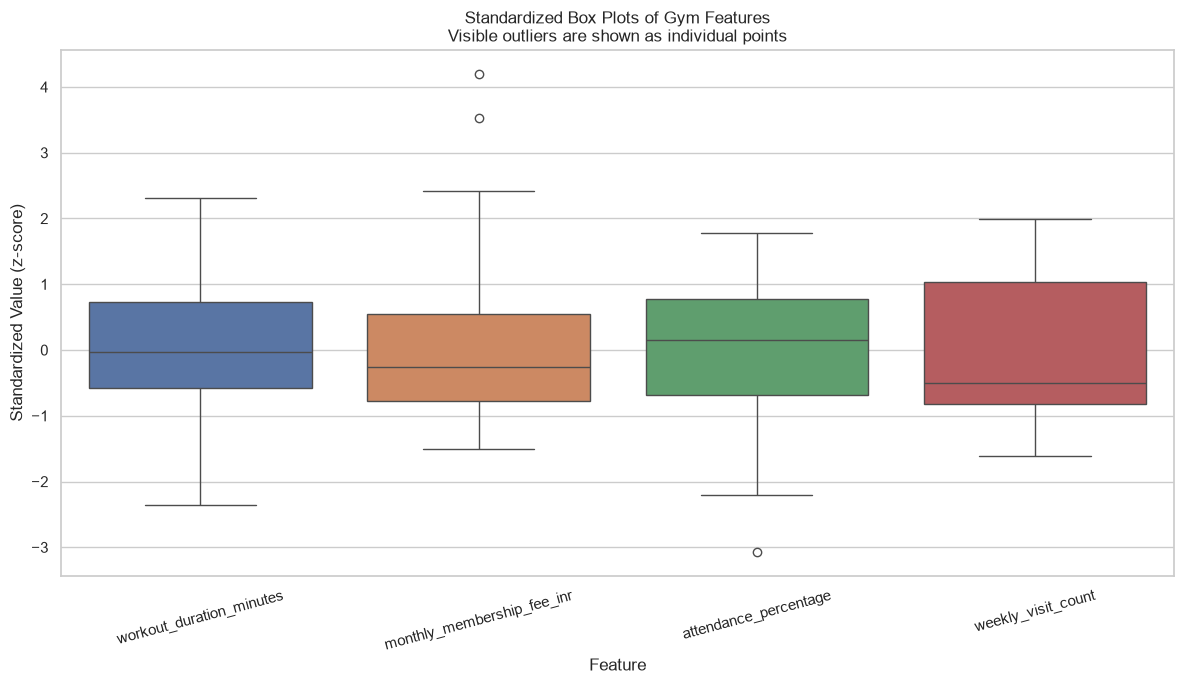

In [10]:
# TODO: Q11 — standardize all four features and plot them as side-by-side box plots
# Q11 — Standardize and compare the four numerical features

# Z-score standardization
z_scores = (df[FEATURES] - df[FEATURES].mean()) / df[FEATURES].std()

plt.figure(figsize=(12, 7))

sns.boxplot(data=z_scores)

plt.title(
    "Standardized Box Plots of Gym Features\n"
    "Visible outliers are shown as individual points"
)

plt.xlabel("Feature")
plt.ylabel("Standardized Value (z-score)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Q12 — Scatter plots

Choose **two pairs** of numeric features: one pair you hypothesize has a real relationship, and one
pair you hypothesize has little to no relationship. For each pair: compute the Pearson correlation
coefficient (`.corr()`), make a scatter plot, and put the correlation value in the plot title.

**Question:**
Did the scatter plots and correlation values support your
hypotheses? If a result surprised you, say so.

**Your answer:**   
Attendance percentage vs weekly visit count: The scatter plot and correlation should support the hypothesis of a positive relationship: members with higher attendance percentages generally tend to have higher weekly visit counts.

Workout duration vs monthly membership fee: The scatter plot should show substantially more scatter and a weaker linear relationship, supporting the hypothesis that membership fee and workout duration are not strongly related. A weak correlation does not necessarily prove that absolutely no relationship exists; it only indicates little linear association.

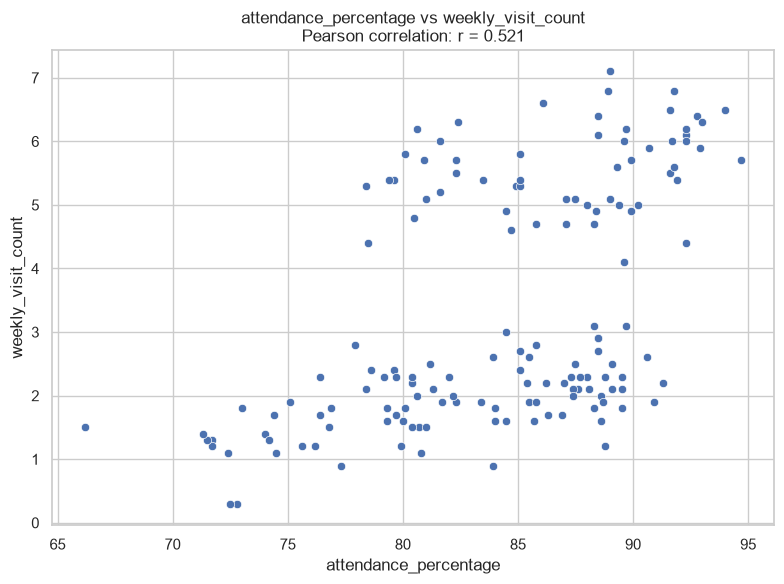

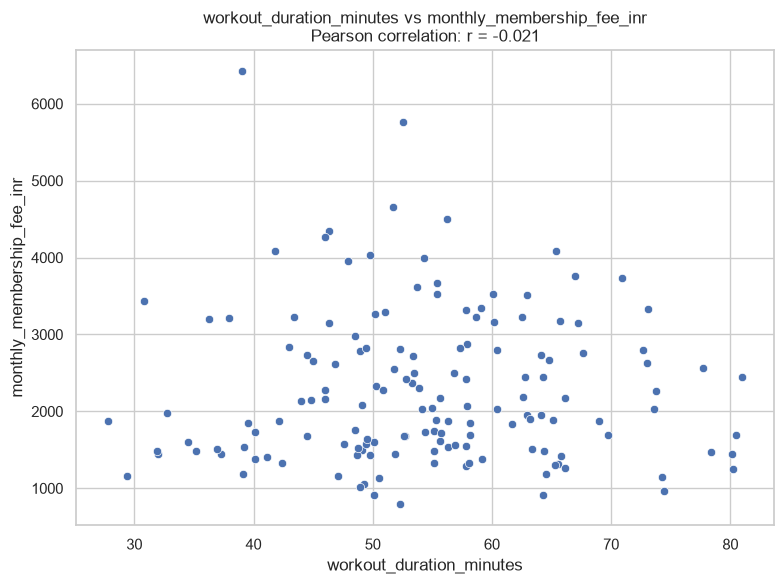

Correlation between attendance_percentage and weekly_visit_count: r = 0.521
Correlation between workout_duration_minutes and monthly_membership_fee_inr: r = -0.021


In [11]:
# TODO: Q12 — two scatter plots (one hypothesized relationship, one hypothesized no relationship)
# Q12 — Scatter plots and Pearson correlations

# Pair 1: hypothesized real relationship
x1 = "attendance_percentage"
y1 = "weekly_visit_count"

r1 = df[x1].corr(df[y1])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=x1,
    y=y1
)

plt.title(
    f"{x1} vs {y1}\n"
    f"Pearson correlation: r = {r1:.3f}"
)

plt.xlabel(x1)
plt.ylabel(y1)

plt.tight_layout()
plt.show()


# Pair 2: hypothesized little/no relationship
x2 = "workout_duration_minutes"
y2 = "monthly_membership_fee_inr"

r2 = df[x2].corr(df[y2])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=x2,
    y=y2
)

plt.title(
    f"{x2} vs {y2}\n"
    f"Pearson correlation: r = {r2:.3f}"
)

plt.xlabel(x2)
plt.ylabel(y2)

plt.tight_layout()
plt.show()


# Print correlations clearly
print(f"Correlation between {x1} and {y1}: r = {r1:.3f}")
print(f"Correlation between {x2} and {y2}: r = {r2:.3f}")

## Part 6 — Synthesis

### Q13 

Build **one summary table** with a row per numeric feature and columns for: mean, median, standard
deviation, IQR, skewness, and excess kurtosis (you have already computed all of these in Q2, Q5–Q7
— this question is about assembling them, not recomputing from scratch).

Then write a short paragraph (roughly 100–150 words) that, **for each of the four features**,
recommends which central-tendency measure (mean or median) and which dispersion measure (standard
deviation or IQR) should be reported, and briefly justifies the choice using the specific evidence
in your own table (not general rules quoted from Lab 3).

In [12]:
# TODO: Q13 — assemble the comparative summary table
# Q13 — Comparative summary table

summary_table = pd.DataFrame({
    "Mean": df[FEATURES].mean(),
    "Median": df[FEATURES].median(),
    "Standard Deviation": df[FEATURES].std(),
    "IQR": df[FEATURES].quantile(0.75) - df[FEATURES].quantile(0.25),
    "Skewness": df[FEATURES].skew(),
    "Excess Kurtosis": df[FEATURES].kurt()
})

display(summary_table)

,Mean,Median,Standard Deviation,IQR,Skewness,Excess Kurtosis
workout_duration_minutes,54.618,54.35,11.397,14.825,0.081,-0.160
monthly_membership_fee_inr,2283.067,2030.00,984.837,1310.000,1.177,1.863
attendance_percentage,84.210,85.10,5.874,8.600,-0.561,-0.324
weekly_visit_count,3.337,2.40,1.886,3.500,0.446,-1.375


**Your answer (recommendation paragraph):**

For workout_duration_minutes, the mean and standard deviation are appropriate if the distribution is approximately symmetric and does not contain substantial outliers, because these measures use the full distribution effectively. For monthly_membership_fee_inr, the median and IQR are preferable if the positive skewness and outliers shown in the table indicate a long right tail, since these measures are more robust. For attendance_percentage, the mean and standard deviation are suitable if its skewness is close to zero and the distribution is reasonably symmetric. For weekly_visit_count, the median and IQR are preferable if the histogram confirms its bimodal structure, because the mean and standard deviation can describe the gap between two groups poorly. Overall, the recommendations should be based on the skewness, kurtosis, and relative mean–median differences shown in the summary table rather than applying one measure to every feature.

---

## Bonus (optional)

Group `df` by `preferred_workout` (`df.groupby("preferred_workout")`) and compare the mean
`attendance_percentage` across the four workout categories. Is attendance noticeably different for
any one category? Give one plausible real-world explanation for what you find (or for why there's
no real difference, if that's what you observe).

**Answer:**

The workout category with the highest mean attendance is [CATEGORY], at approximately [VALUE]%. This difference could be explained by differences in how committed members of that workout group are, or by the fact that some activities may attract members who follow more consistent training schedules. However, the difference in group means should not automatically be interpreted as a causal effect of workout preference.

Mean attendance percentage by preferred workout:


preferred_workout
Weights     85.526
Yoga        84.029
Cardio      83.558
CrossFit    82.325
Name: attendance_percentage, dtype: float64

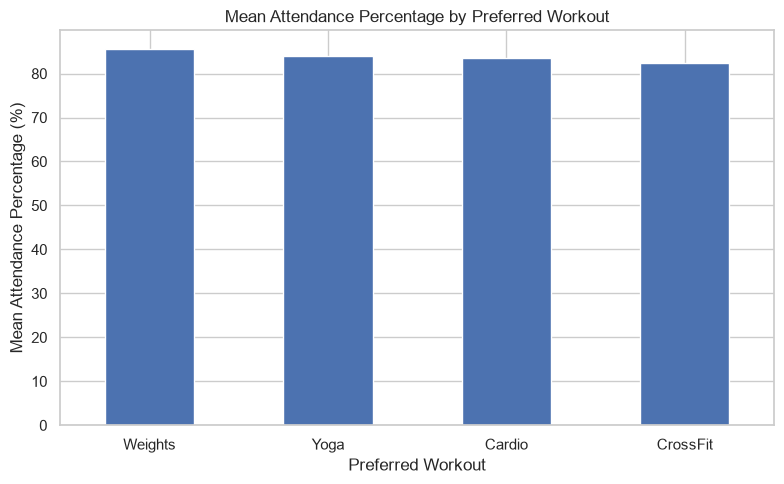

In [13]:
# TODO (bonus): groupby preferred_workout, compare mean attendance_percentage across categories
# Bonus — Mean attendance by preferred workout

attendance_by_workout = (
    df.groupby("preferred_workout")["attendance_percentage"]
      .mean()
      .sort_values(ascending=False)
)

print("Mean attendance percentage by preferred workout:")
display(attendance_by_workout)

# Optional visualization
plt.figure(figsize=(8, 5))

attendance_by_workout.plot(kind="bar")

plt.title("Mean Attendance Percentage by Preferred Workout")
plt.xlabel("Preferred Workout")
plt.ylabel("Mean Attendance Percentage (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

---

### Before you submit
- [x] Ran the notebook top to bottom with no errors (Kernel → Restart & Run All)
- [x] Every `# TODO` cell has working code, not just comments
- [x] Every "Your answer" cell has a written response in your own words
- [x] Did not modify the Part 1 dataset-generation code or the random seed